### Second Price Auction with Common Value

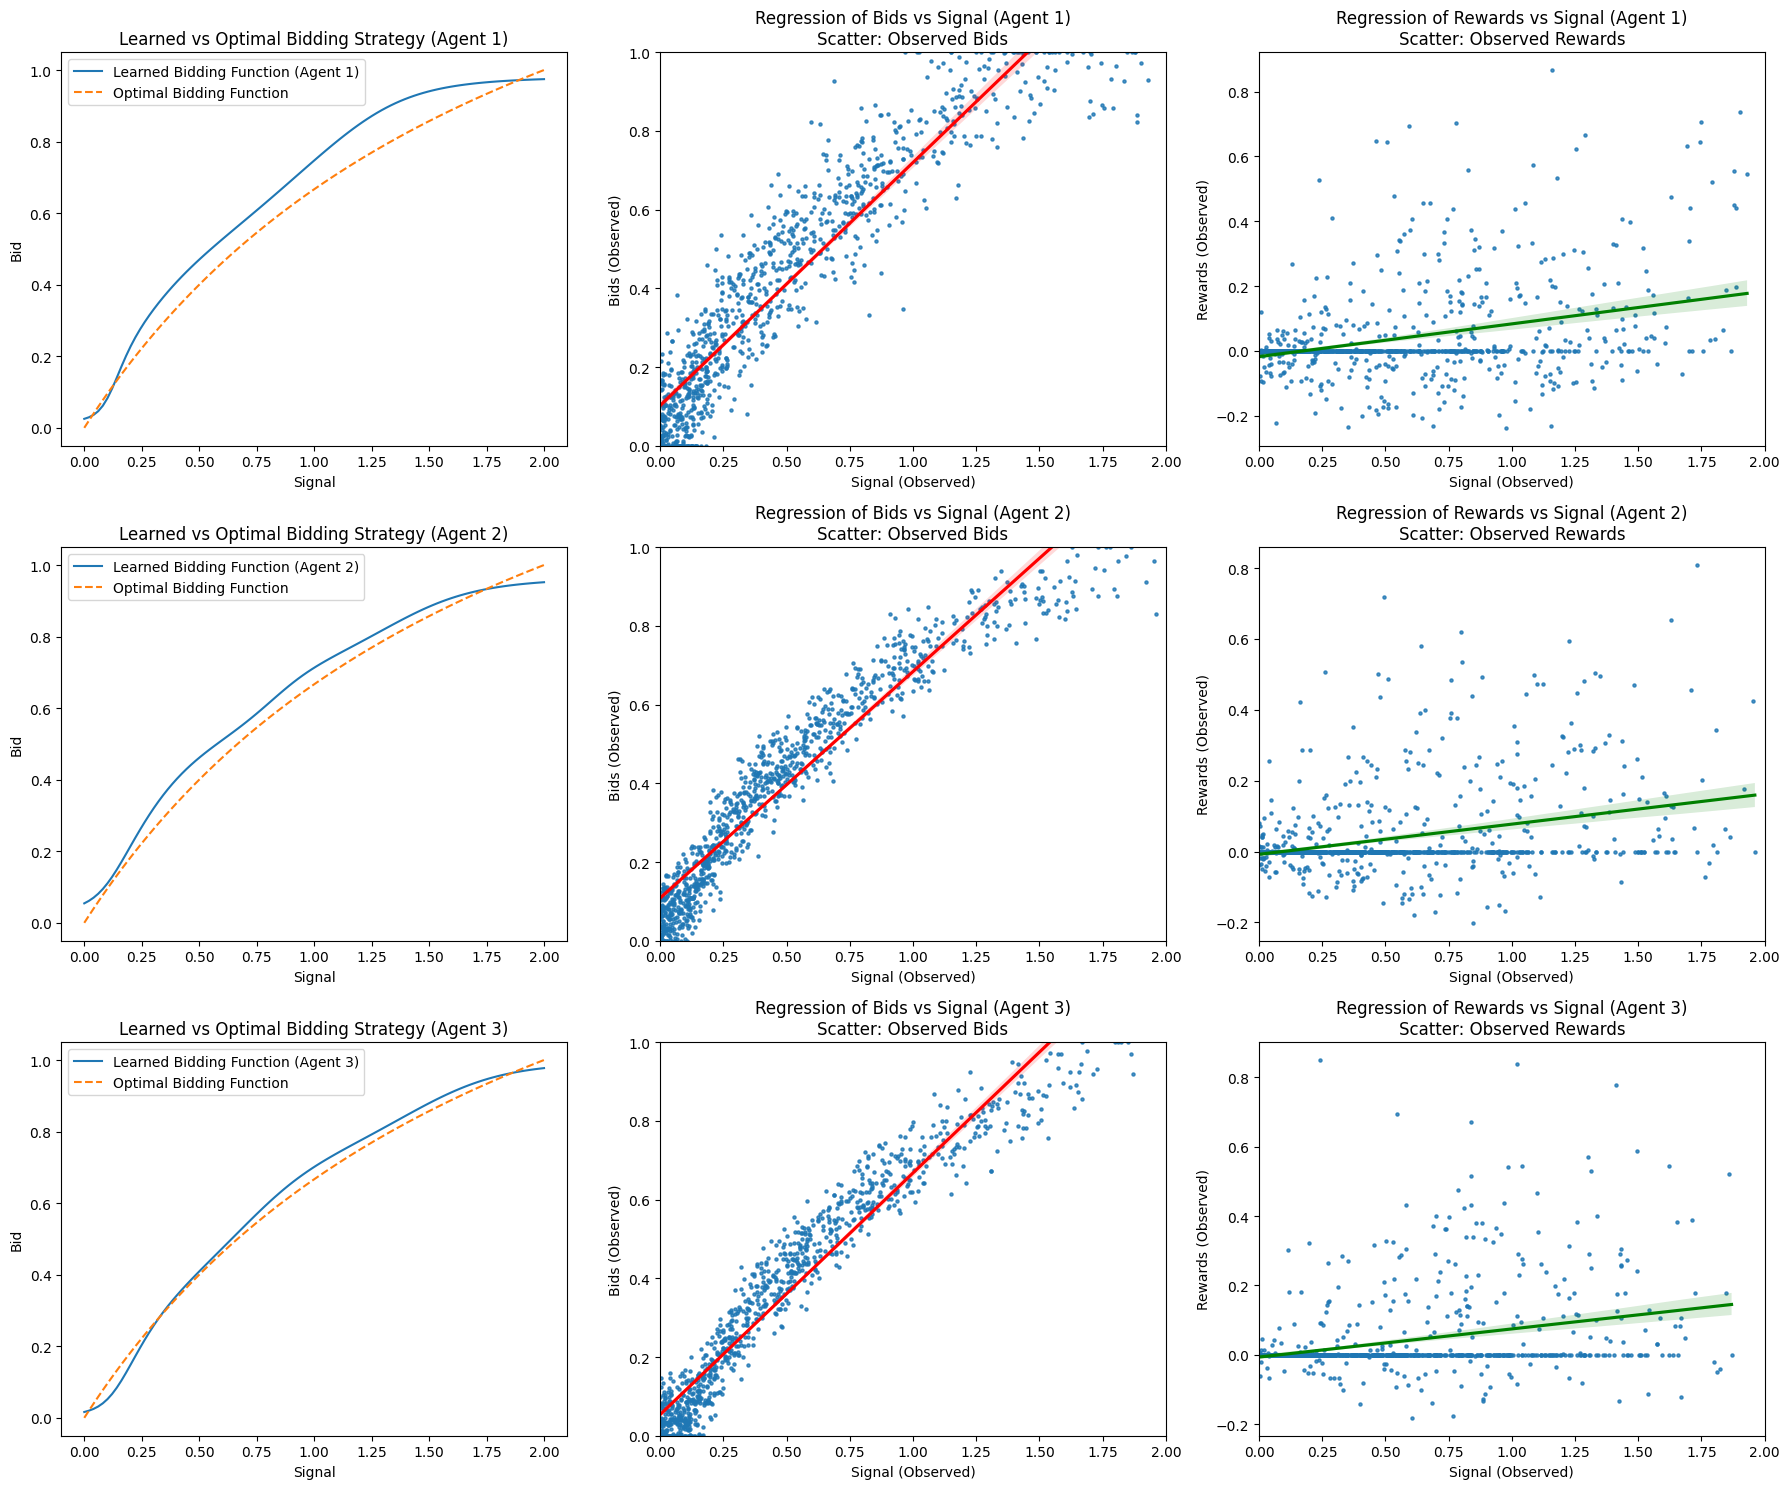

Iteration 150/1000, Average Rewards: [0.04244619612205494, 0.036774839633651975, 0.03463225046671371]


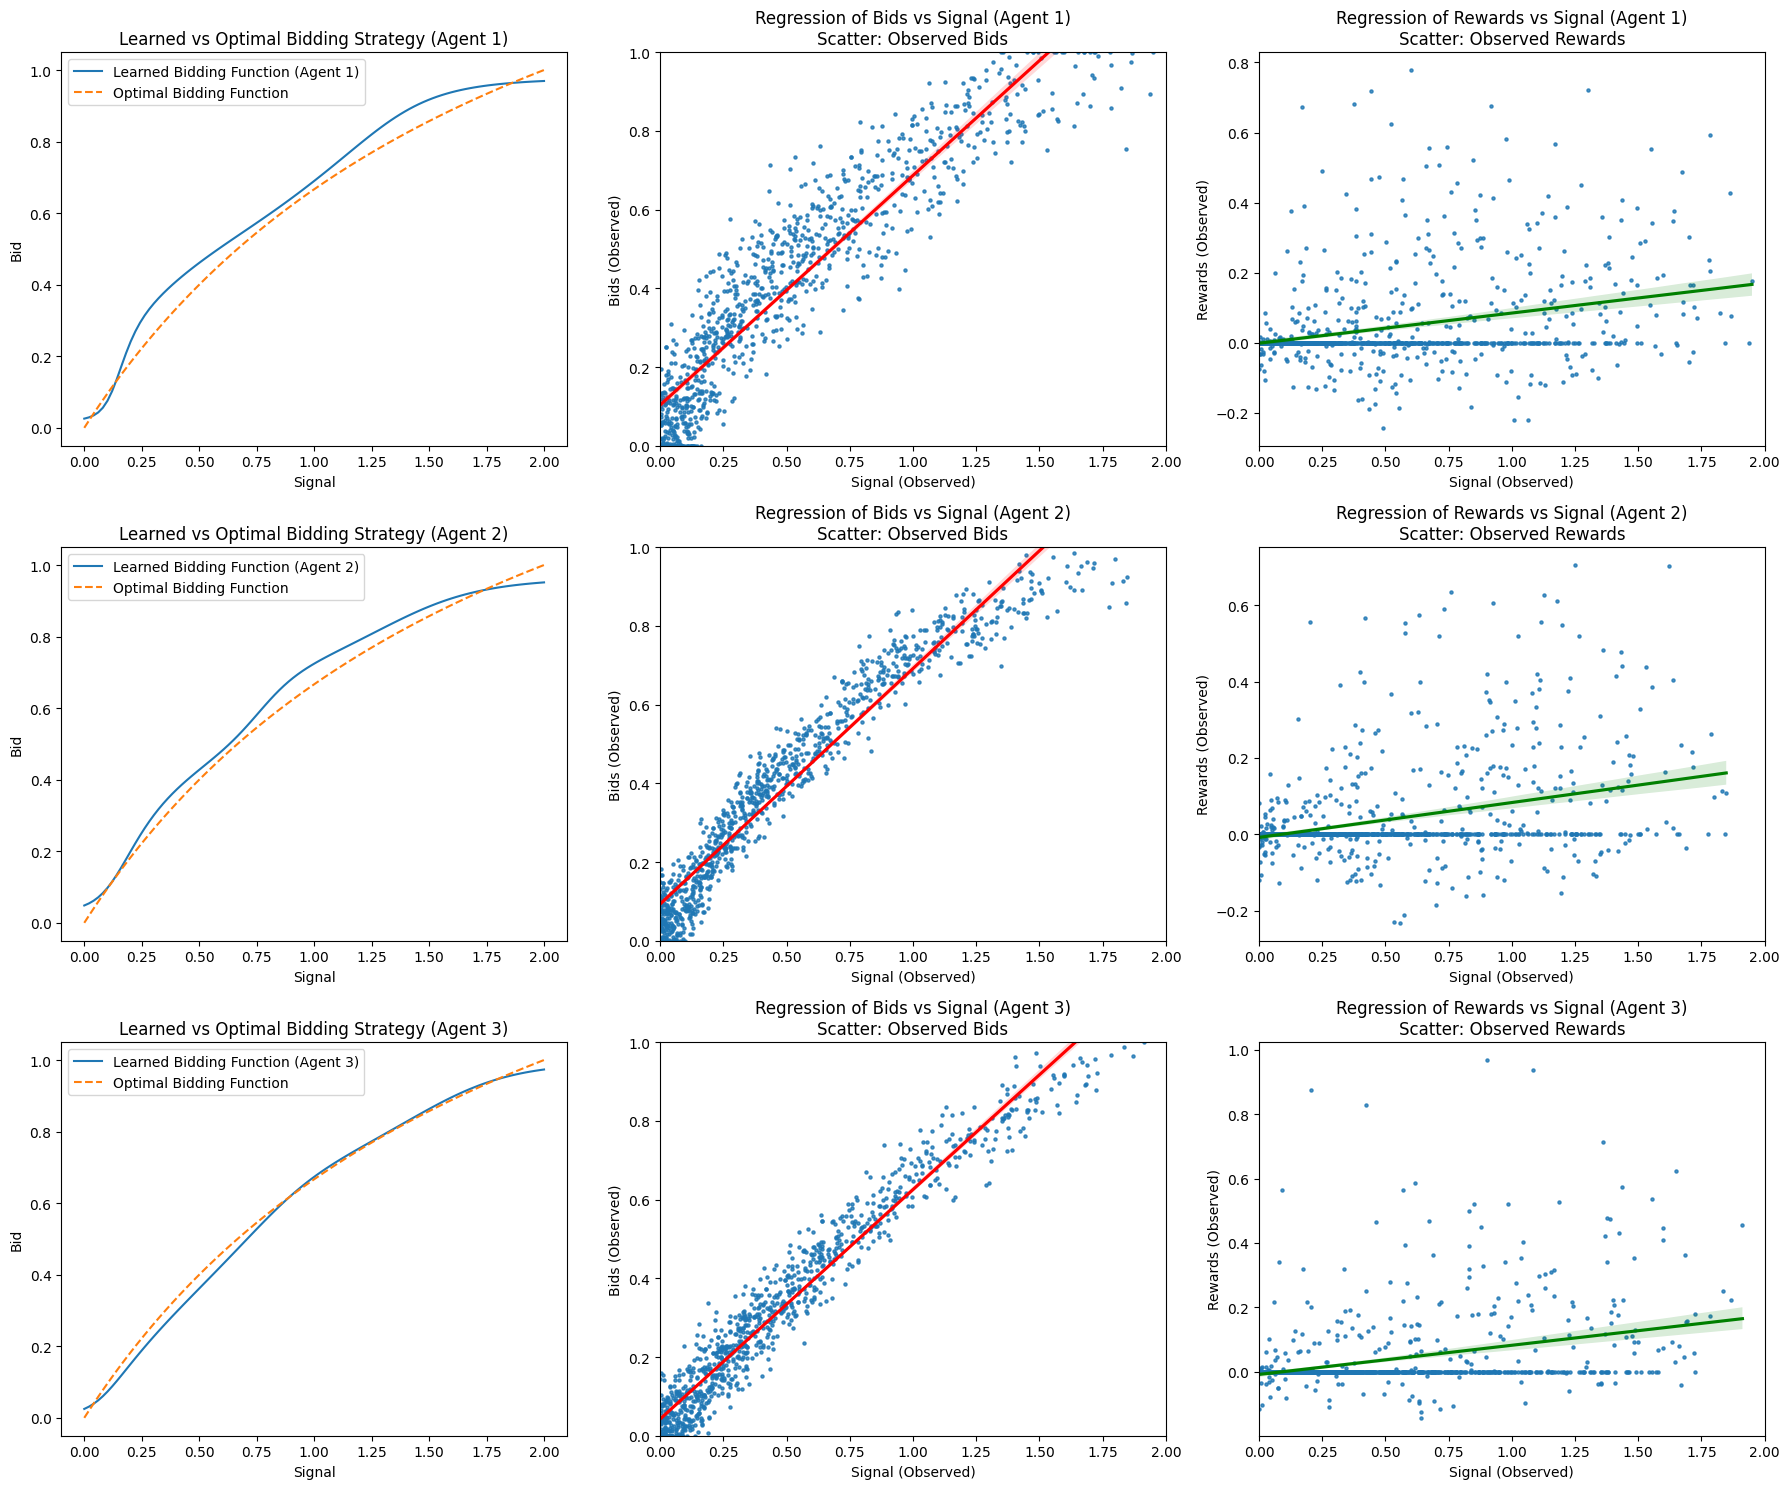

KeyboardInterrupt: 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
import gym
from gym import spaces
import matplotlib.pyplot as plt
import seaborn as sns

# Define the Auction Environment for Common Value Auction with Second-Price
class CommonValueSecondPriceAuctionEnv(gym.Env):
    def __init__(self, num_agents=3, common_value_distribution=lambda: np.random.uniform(0, 1)):
        super(CommonValueSecondPriceAuctionEnv, self).__init__()
        self.num_agents = num_agents
        self.common_value_distribution = common_value_distribution
        self.observation_space = spaces.Box(low=0.0, high=2.0, shape=(1,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        self.reset()

    def reset(self):
        self.common_value = self.common_value_distribution()
        self.signals = [np.random.uniform(0, 2 * self.common_value) for _ in range(self.num_agents)]
        self.states = [np.array([s], dtype=np.float32) for s in self.signals]
        return self.states

    def step(self, actions):
        bids = [np.clip(a[0], 0.0, 1.0) for a in actions]
        sorted_indices = np.argsort(bids)
        winner = sorted_indices[-1]
        if len(bids) > 1:
            payment = bids[sorted_indices[-2]]  # Second highest bid
        else:
            payment = 0.0  # In case there is only one bidder
        rewards = [0.0 for _ in range(self.num_agents)]
        rewards[winner] = self.common_value - payment
        done = True
        info = {'bids': bids, 'signals': self.signals, 'winner': winner}
        next_states = self.reset()
        return next_states, rewards, done, info

    def render(self, mode='human'):
        pass

# Define the PPO Agent
class PPOAgent(nn.Module):
    def __init__(self, observation_space, action_space, action_bound_method='clamp', lr=3e-4):
        super(PPOAgent, self).__init__()
        self.observation_space = observation_space
        self.action_space = action_space
        self.action_bound_method = action_bound_method
        self.lr = lr

        self.actor = nn.Sequential(
            nn.Linear(observation_space.shape[0], 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, action_space.shape[0]),
            nn.Sigmoid(),  # Output between 0 and 1
        )
        self.critic = nn.Sequential(
            nn.Linear(observation_space.shape[0], 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.log_std = nn.Parameter(torch.zeros(action_space.shape[0]))

        self.optimizer = optim.Adam(self.parameters(), lr=self.lr)

    def get_action(self, x):
        mean = self.actor(x)  # Actor outputs between 0 and 1
        std = self.log_std.exp()
        dist = Normal(mean, std)
        action = dist.sample()
        if self.action_bound_method == 'clamp':
            action = torch.clamp(action, 0.0, 1.0)
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action, log_prob

    def get_value(self, x):
        return self.critic(x)

    def compute_loss(self, obs_batch, actions_batch, log_probs_old, returns, advantages, epsilon=0.2):
        # Actor loss
        mean = self.actor(obs_batch)
        std = self.log_std.exp()
        dist = Normal(mean, std)
        actions_bound = torch.clamp(actions_batch, 0.0, 1.0)
        log_probs = dist.log_prob(actions_bound).sum(dim=-1)
        ratios = torch.exp(log_probs - log_probs_old)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - epsilon, 1 + epsilon) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()
        # Critic loss
        values = self.critic(obs_batch).squeeze()
        critic_loss = nn.MSELoss()(values, returns)
        # Entropy bonus
        entropy = dist.entropy().sum(dim=-1).mean()
        # Total loss
        loss = actor_loss + 0.5 * critic_loss - 0.005 * entropy
        return loss

    def update(self, loss):
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# Define the optimal bid rule for the second-price auction with common values
def optimal_bid(x):
    return 2 * x / (2 + x)

# Training Parameters
num_iterations = 1000  # Number of training iterations
batch_size = 1000       # Number of auctions per iteration
learning_rate = 3e-3
gamma = 0.0           # Immediate reward only
epsilon = 0.1         # PPO clipping epsilon
num_epochs = 4        # PPO epochs
num_minibatches = 4   # Number of minibatches for PPO update

# Create Environment and Agents for Common Value Auction
env = CommonValueSecondPriceAuctionEnv(num_agents=3)  # Common value auction environment with 3 bidders
agents = [PPOAgent(env.observation_space, env.action_space, action_bound_method='clamp', lr=learning_rate)
          for _ in range(env.num_agents)]

# Training Loop
for iteration in range(num_iterations):
    # Initialize data structures for each agent
    obs_batch = [[] for _ in range(env.num_agents)]
    actions_batch = [[] for _ in range(env.num_agents)]
    rewards_batch = [[] for _ in range(env.num_agents)]
    log_probs_batch = [[] for _ in range(env.num_agents)]
    values_batch = [[] for _ in range(env.num_agents)]
    
    # To track observed bids and rewards for all agents
    observed_signals = [[] for _ in range(env.num_agents)]
    observed_bids = [[] for _ in range(env.num_agents)]
    observed_rewards = [[] for _ in range(env.num_agents)]

    # Reset environment
    states = env.reset()

    for _ in range(batch_size):
        actions = []
        for i in range(env.num_agents):
            obs = states[i]
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            action, log_prob = agents[i].get_action(obs_tensor)
            value = agents[i].get_value(obs_tensor)

            action_np = action.detach().numpy()[0]
            actions.append(action_np)

            # Store data
            obs_batch[i].append(obs)
            actions_batch[i].append(action_np)
            log_probs_batch[i].append(log_prob.detach().numpy())
            values_batch[i].append(value.detach().numpy()[0])

        # Step environment with all actions
        next_states, rewards, done, _ = env.step(actions)

        # Track observed data for all agents
        for i in range(env.num_agents):
            observed_signals[i].append(states[i][0])  # Signal for agent i
            observed_bids[i].append(actions[i])       # Bid for agent i
            observed_rewards[i].append(rewards[i])    # Reward for agent i

        # Store rewards
        for i in range(env.num_agents):
            rewards_batch[i].append(rewards[i])

        # Update states
        states = next_states

    # PPO Update for each agent
    for i in range(env.num_agents):
        obs_batch_i = torch.tensor(obs_batch[i], dtype=torch.float32)
        actions_batch_i = torch.tensor(actions_batch[i], dtype=torch.float32)
        rewards_batch_i = torch.tensor(rewards_batch[i], dtype=torch.float32)
        log_probs_batch_i = torch.tensor(log_probs_batch[i], dtype=torch.float32).squeeze()
        values_batch_i = torch.tensor(values_batch[i], dtype=torch.float32).squeeze()

        # Compute Advantages and Returns
        returns = rewards_batch_i  # Since gamma=0, returns are immediate rewards
        advantages = returns - values_batch_i.detach()

        # Normalize Advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # PPO Update
        for _ in range(num_epochs):
            indices = np.arange(batch_size)
            np.random.shuffle(indices)
            minibatch_size = batch_size // num_minibatches
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = indices[start:end]

                mb_obs = obs_batch_i[mb_inds]
                mb_actions = actions_batch_i[mb_inds]
                mb_log_probs_old = log_probs_batch_i[mb_inds]
                mb_advantages = advantages[mb_inds]
                mb_returns = returns[mb_inds]

                # Compute loss
                loss = agents[i].compute_loss(mb_obs, mb_actions, mb_log_probs_old, mb_returns, mb_advantages, epsilon)

                # Update agent
                agents[i].update(loss)

    # Optional: Print progress and plot every 10 iterations
    if (iteration + 1) % 10 == 0:
        avg_rewards = [np.mean(rewards_batch[i]) for i in range(env.num_agents)]
        print(f"Iteration {iteration + 1}/{num_iterations}, Average Rewards: {avg_rewards}")

        # Create Kx3 grid plot for all agents (K is the number of agents)
        fig, axes = plt.subplots(env.num_agents, 3, figsize=(18, 5 * env.num_agents))

        signals = np.linspace(0, 2, 100)
        
        for i in range(env.num_agents):
            bids_agent = []
            for v in signals:
                obs_tensor = torch.tensor([v], dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    mean = agents[i].actor(obs_tensor)
                    bid = torch.clamp(mean, 0.0, 1.0).numpy()[0][0]
                bids_agent.append(bid)

            # 1. Plot the Learned Bidding Function for Agent i
            axes[i, 0].plot(signals, bids_agent, label=f'Learned Bidding Function (Agent {i+1})')
            axes[i, 0].plot(signals, optimal_bid(signals), label='Optimal Bidding Function', linestyle='--')
            axes[i, 0].set_xlabel('Signal')
            axes[i, 0].set_ylabel('Bid')
            axes[i, 0].set_title(f'Learned vs Optimal Bidding Strategy (Agent {i+1})')
            axes[i, 0].legend()

            # 2. Plot regression of bids vs observed signals for Agent i
            sns.regplot(x=observed_signals[i], y=observed_bids[i], scatter_kws={'s':5}, line_kws={"color":"r"}, ax=axes[i, 1])
            axes[i, 1].set_xlabel('Signal (Observed)')
            axes[i, 1].set_ylabel('Bids (Observed)')
            axes[i, 1].set_xlim(0, 2)
            axes[i, 1].set_ylim(0, 1)
            axes[i, 1].set_title(f'Regression of Bids vs Signal (Agent {i+1})\nScatter: Observed Bids')

            # 3. Plot regression of rewards vs observed signals for Agent i
            sns.regplot(x=observed_signals[i], y=observed_rewards[i], scatter_kws={'s':5}, line_kws={"color":"g"}, ax=axes[i, 2])
            axes[i, 2].set_xlabel('Signal (Observed)')
            axes[i, 2].set_ylabel('Rewards (Observed)')
            axes[i, 2].set_xlim(0, 2)
            axes[i, 2].set_title(f'Regression of Rewards vs Signal (Agent {i+1})\nScatter: Observed Rewards')

        plt.tight_layout()
        plt.show()


### First Price Auction with Affliated Values

Iteration 10/1000, Average Rewards: [0.266038180887306, 0.30486452944596604]


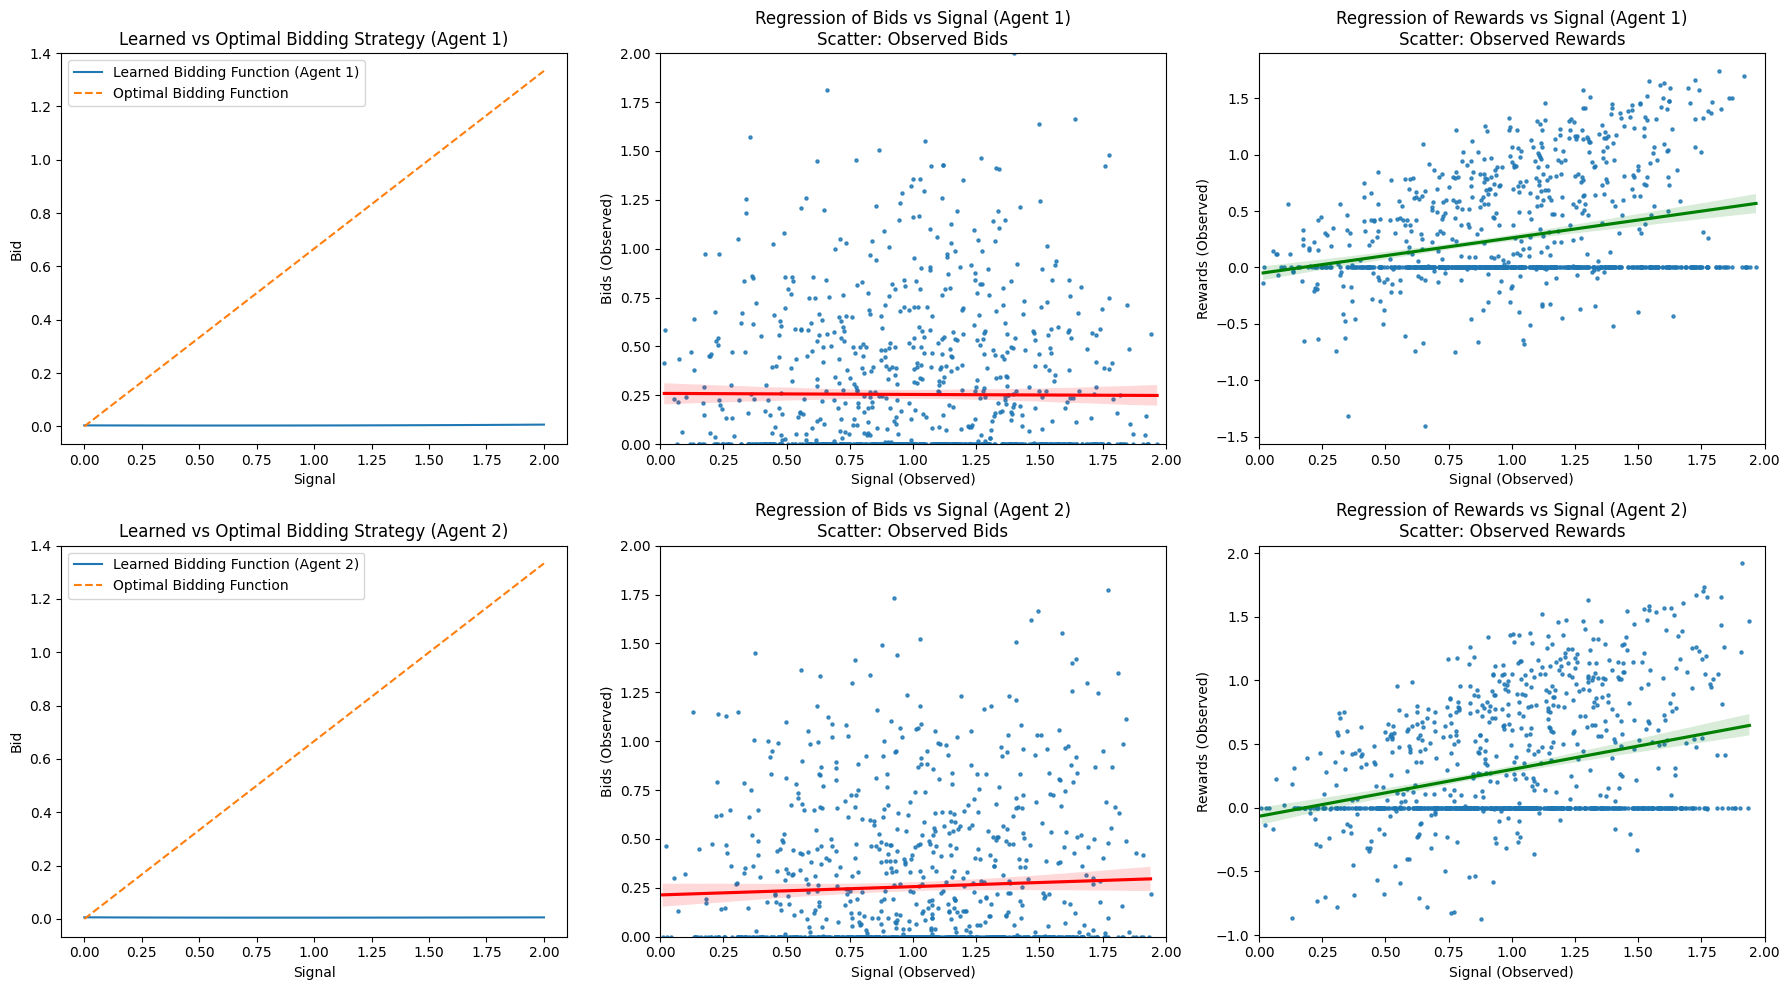

Iteration 20/1000, Average Rewards: [0.3051814029460149, 0.3480757241317725]


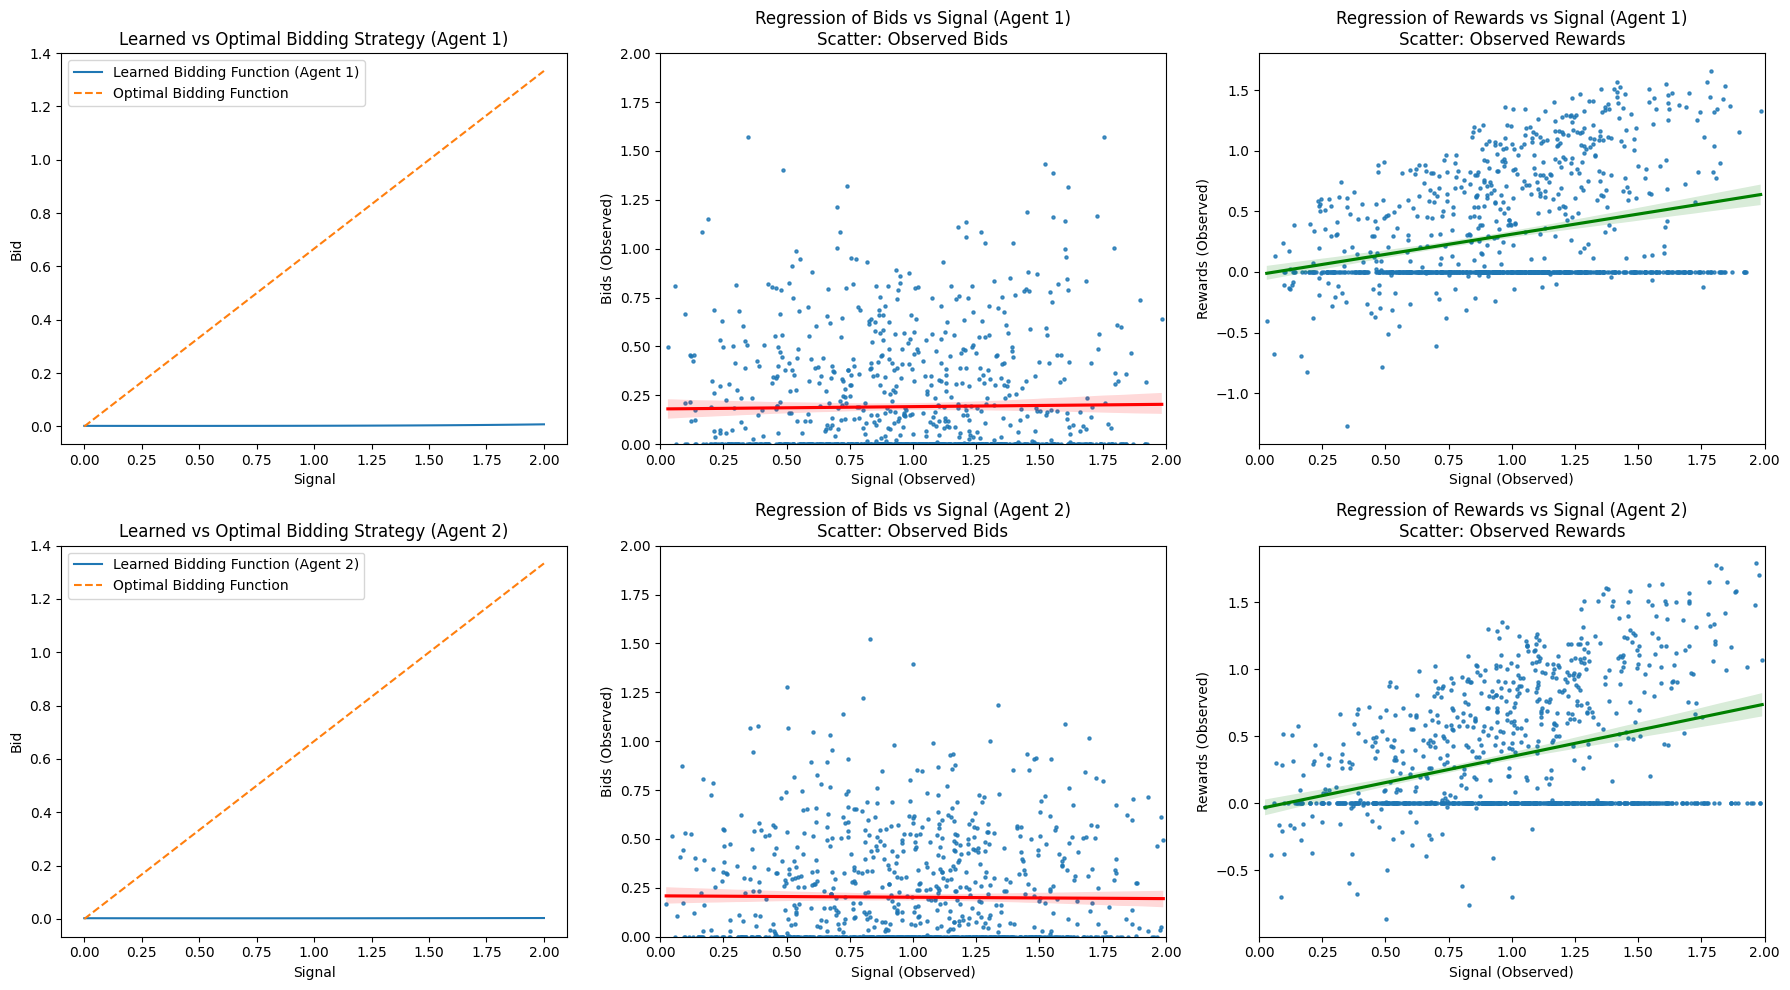

Iteration 30/1000, Average Rewards: [0.3449275562365001, 0.294073896962287]


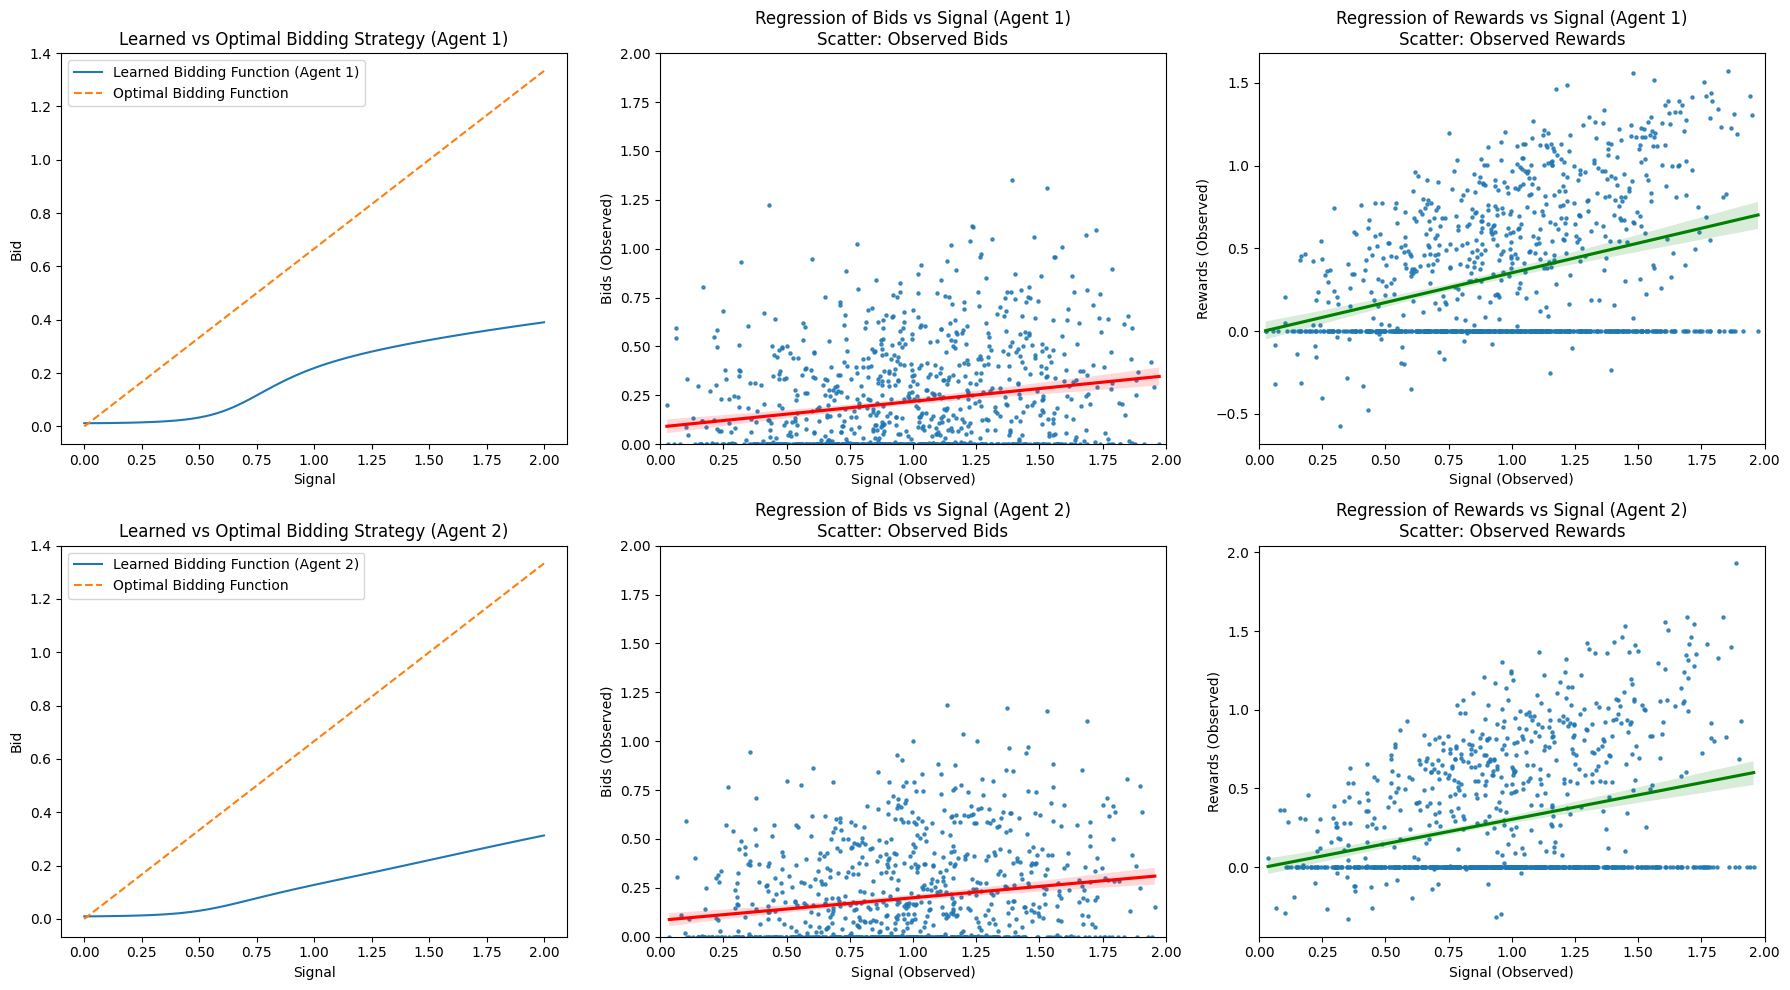

Iteration 40/1000, Average Rewards: [0.25338383793459707, 0.21245300052258098]


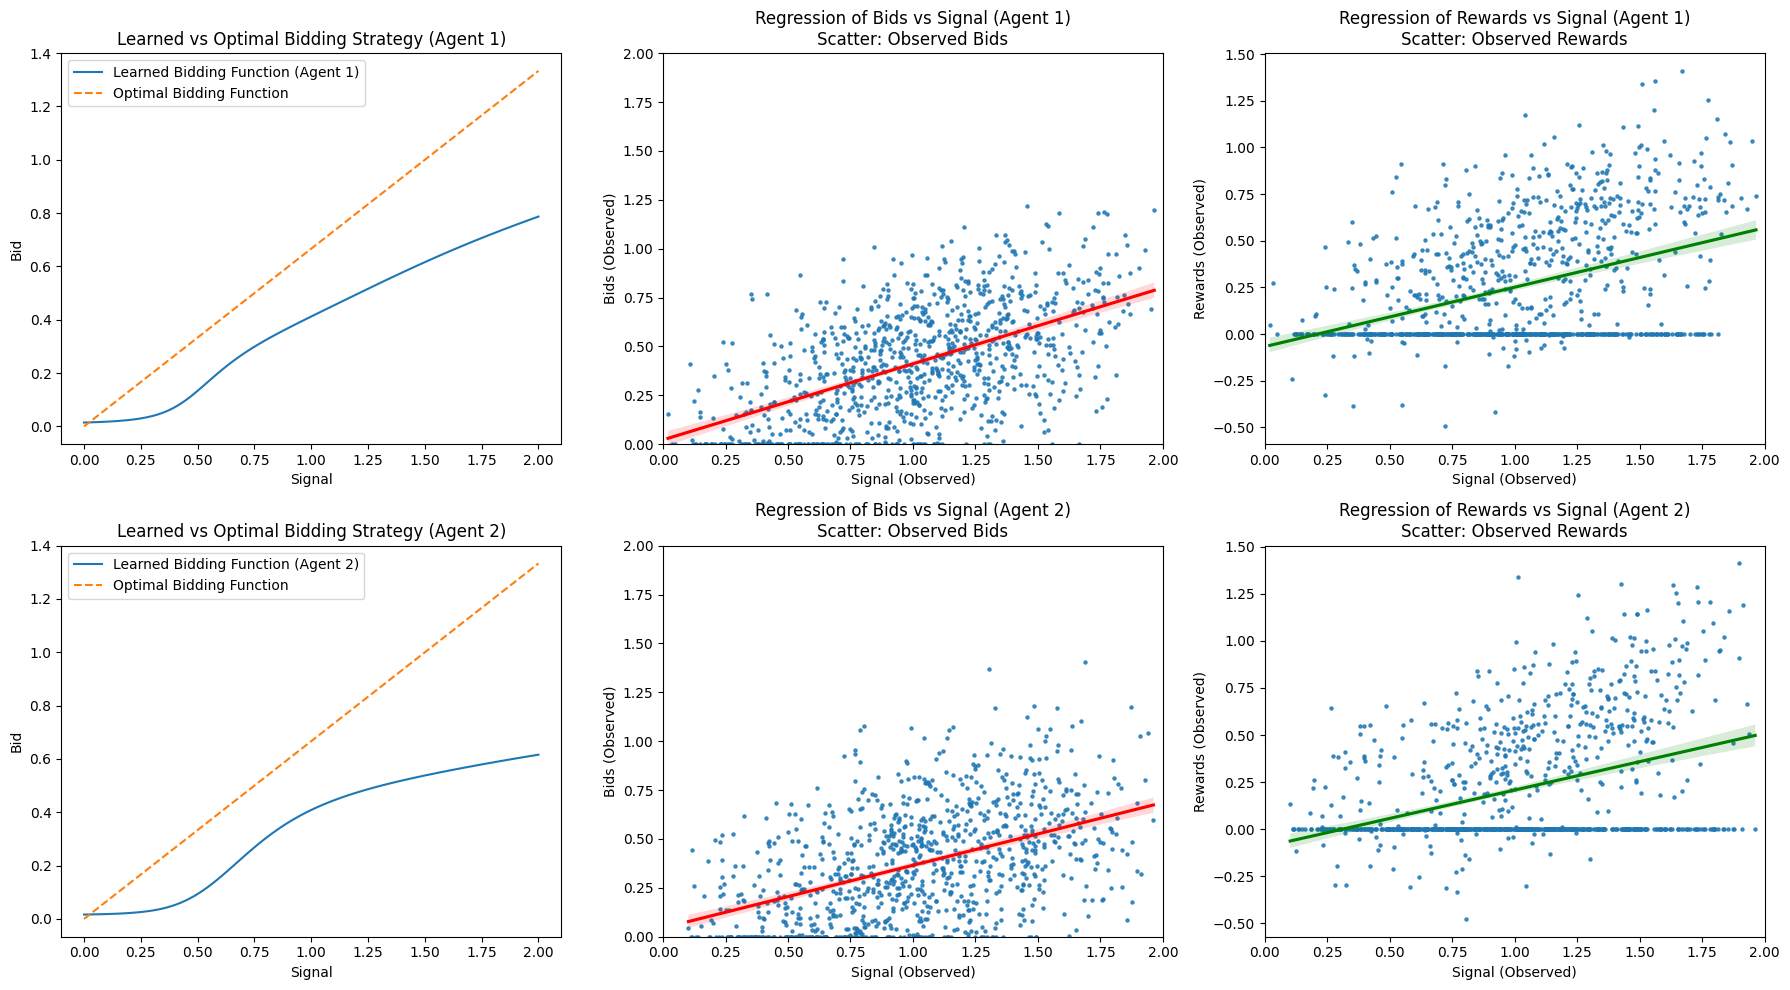

Iteration 50/1000, Average Rewards: [0.2217982070656414, 0.21438448368088928]


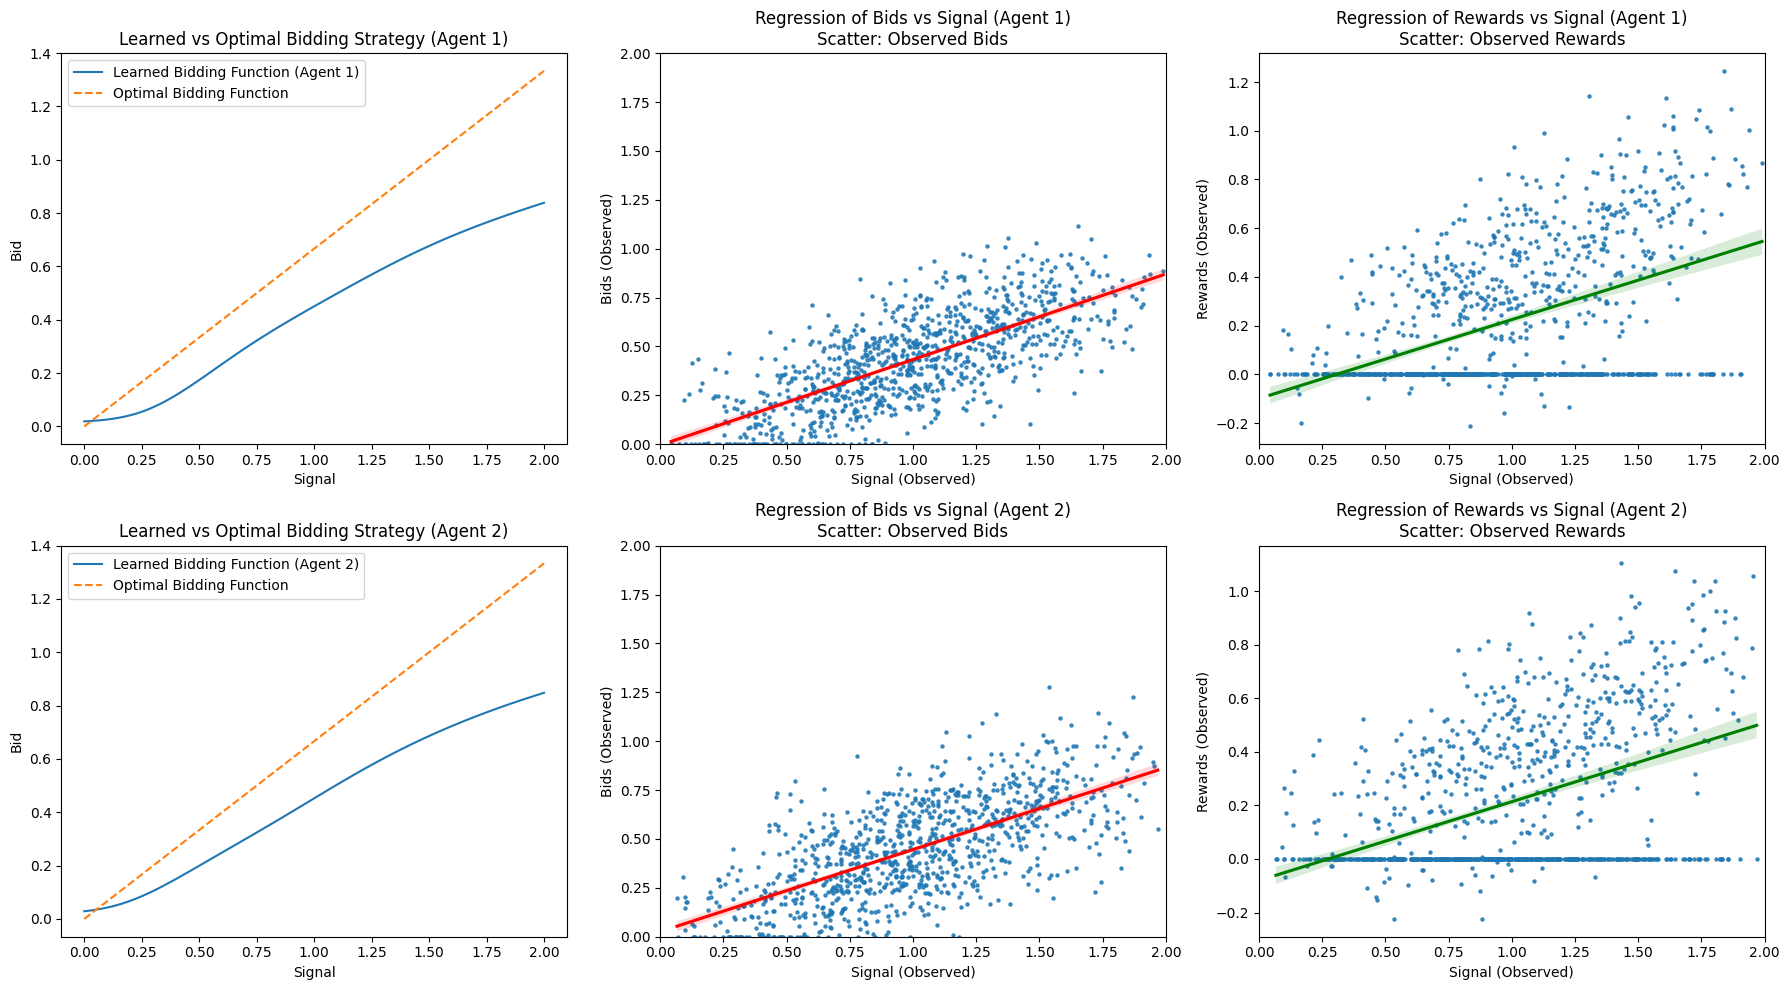

Iteration 60/1000, Average Rewards: [0.13624945698778052, 0.18608358120397717]


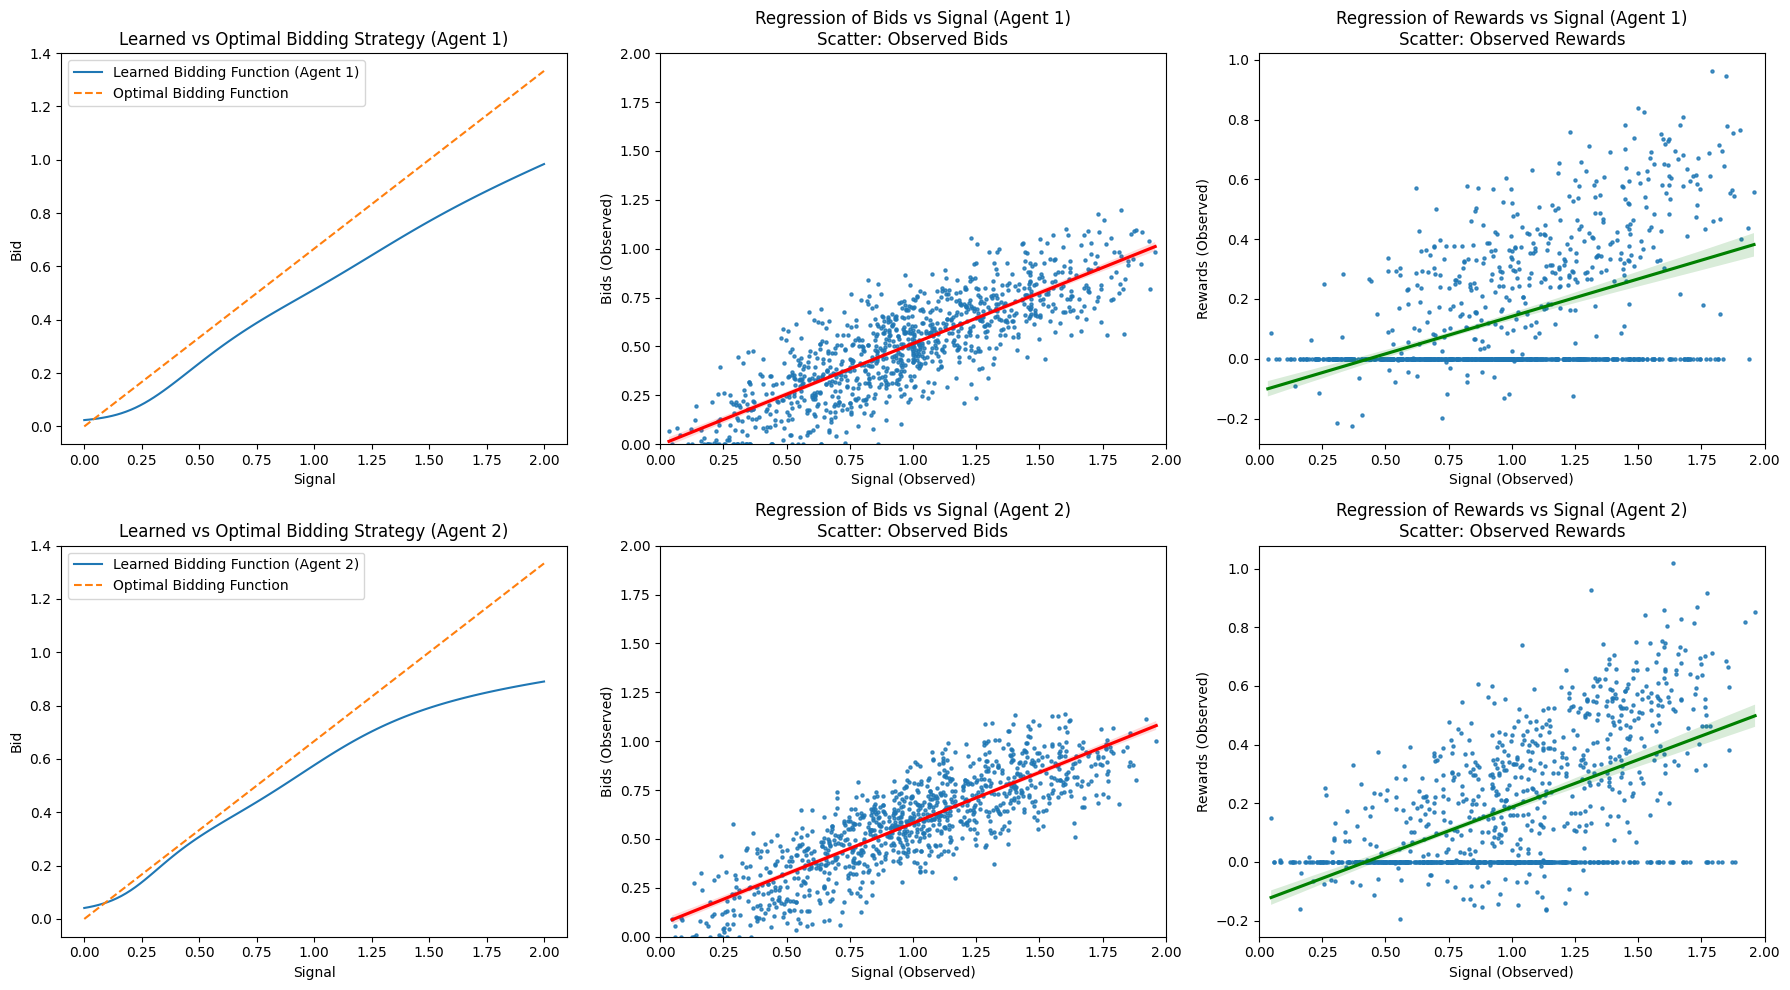

Iteration 70/1000, Average Rewards: [0.1503639781674026, 0.14933206844539673]


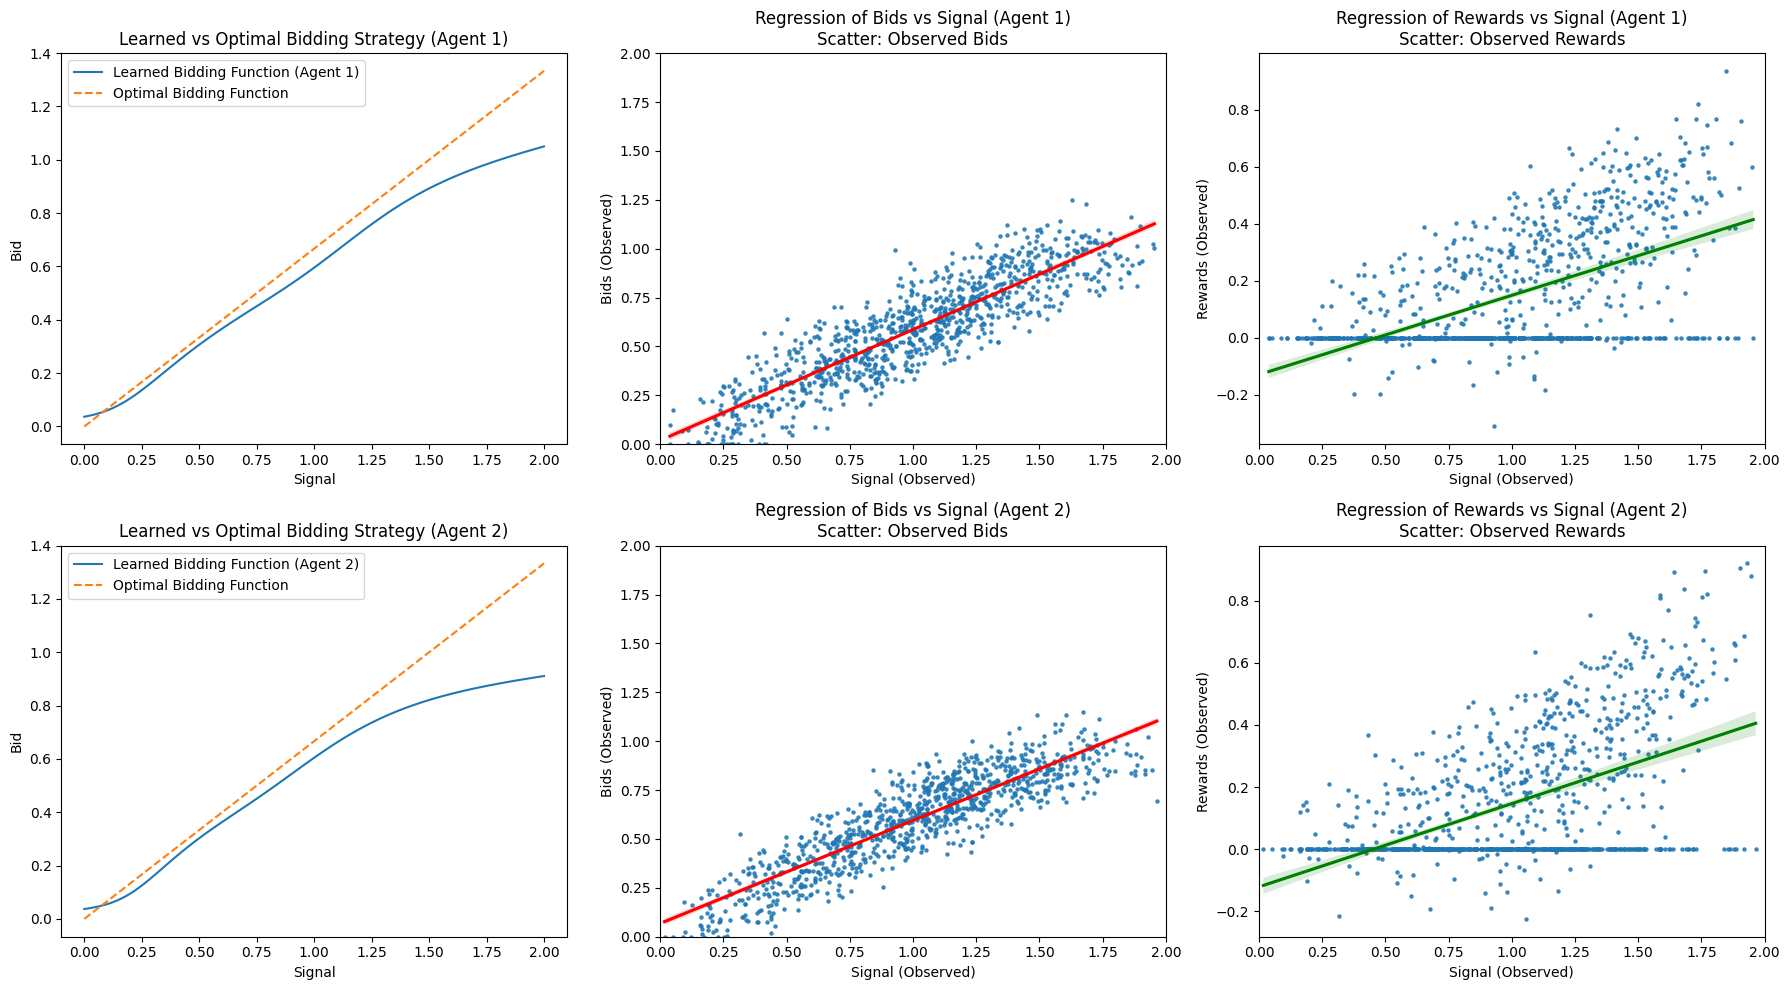

Iteration 80/1000, Average Rewards: [0.15338522811337224, 0.12165000141612524]


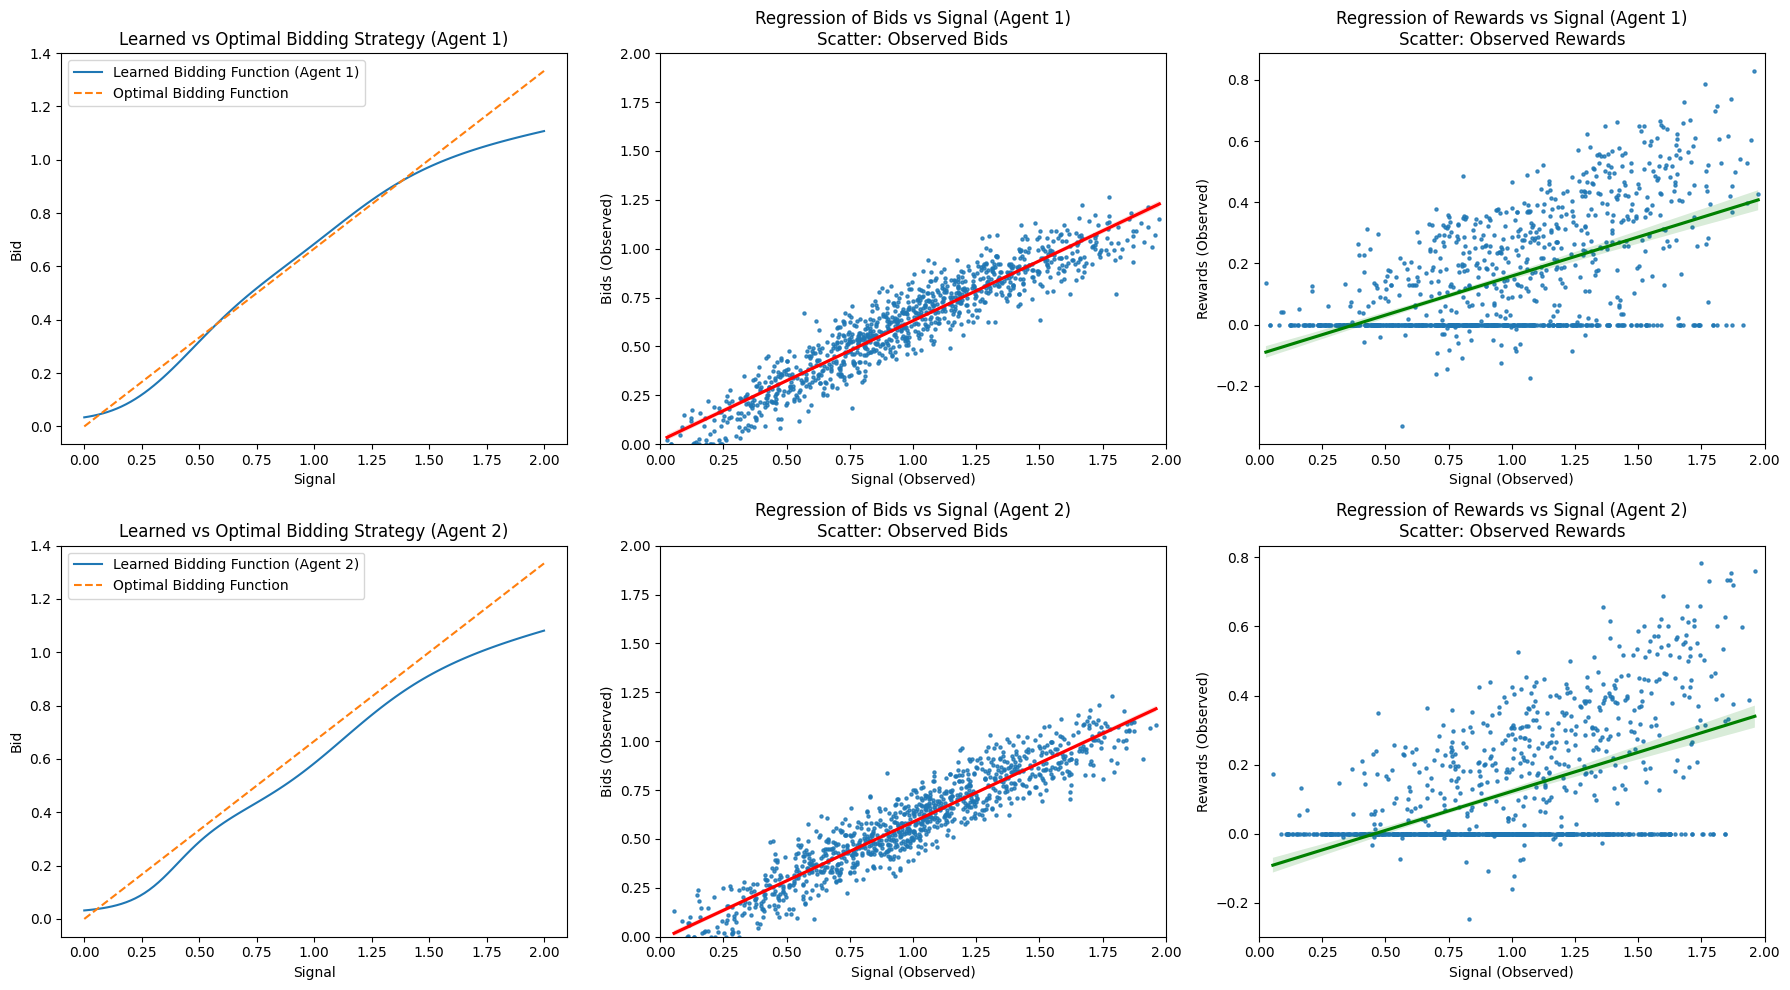

Iteration 90/1000, Average Rewards: [0.15851546820642057, 0.10552361864743648]


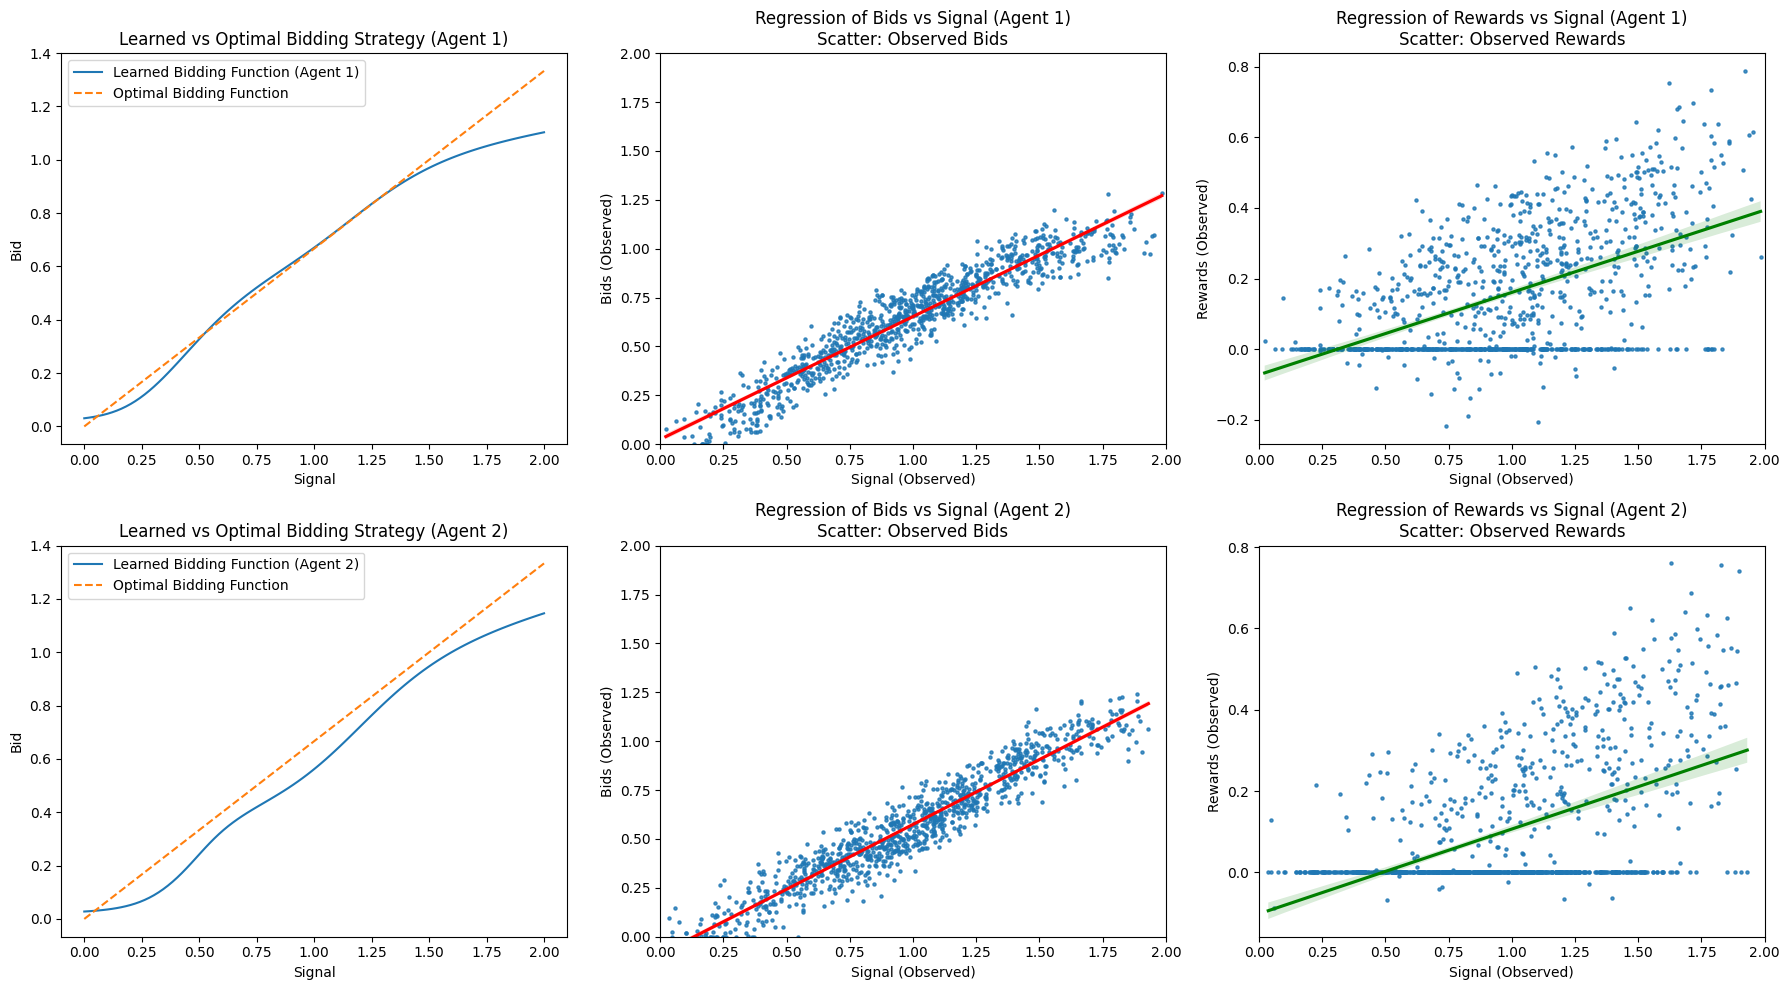

Iteration 100/1000, Average Rewards: [0.14749999151869345, 0.10789201147007028]


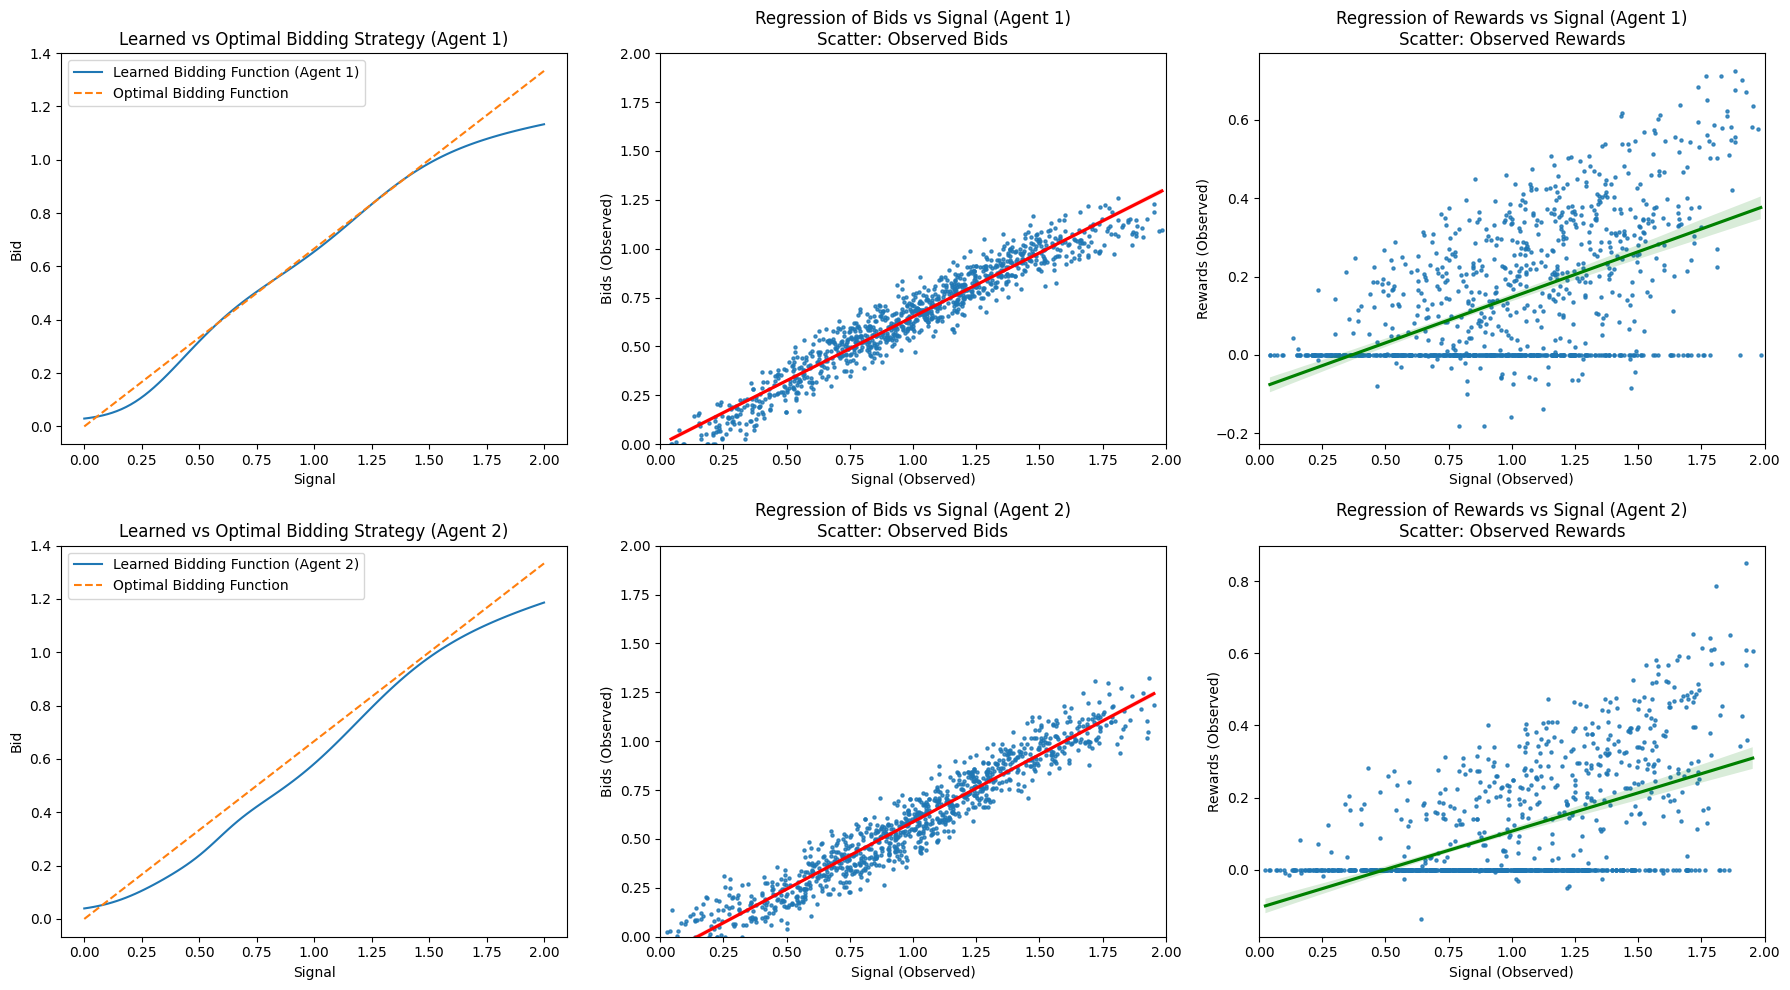

Iteration 110/1000, Average Rewards: [0.12988301649854522, 0.11429006466892158]


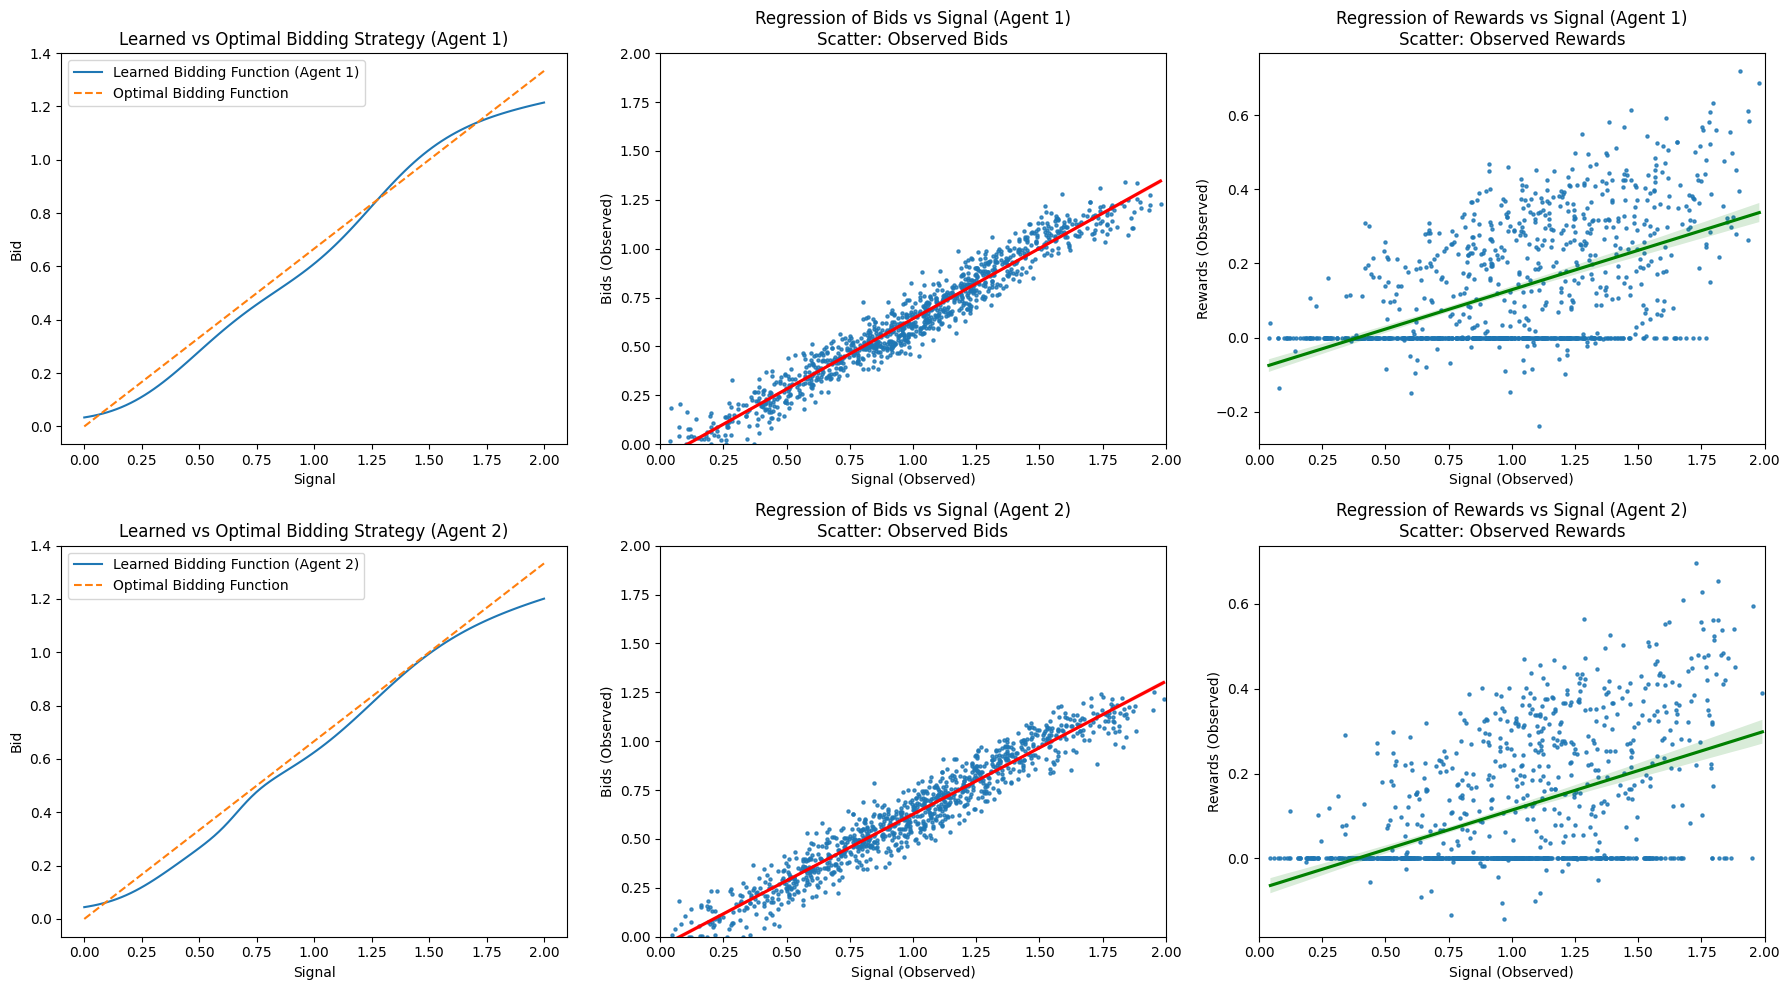

KeyboardInterrupt: 

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
import gym
from gym import spaces
import matplotlib.pyplot as plt
import seaborn as sns

# Define the Auction Environment for First-Price Auction with Custom Signals
class FirstPriceAuctionEnv(gym.Env):
    def __init__(self, num_agents=2):
        super(FirstPriceAuctionEnv, self).__init__()
        self.num_agents = num_agents
        self.observation_space = spaces.Box(low=0.0, high=2.0, shape=(1,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.0, high=2.0, shape=(1,), dtype=np.float32)
        self.reset()

    def reset(self):
        # Draw S1, S2, T ~ Uniform(0,1)
        self.S1 = np.random.uniform(0, 1)
        self.S2 = np.random.uniform(0, 1)
        self.T = np.random.uniform(0, 1)
        # Signals for each bidder
        self.signals = [self.S1 + self.T, self.S2 + self.T]
        # Observations are the signals
        self.states = [np.array([s], dtype=np.float32) for s in self.signals]
        # True valuation V = (X1 + X2)/2
        self.V = (self.signals[0] + self.signals[1]) / 2
        return self.states

    def step(self, actions):
        # actions: list of actions (bids) from each agent
        bids = [np.clip(a[0], 0.0, 2.0) for a in actions]
        # Determine the winner (highest bid)
        max_bid = np.max(bids)
        winner_indices = np.where(bids == max_bid)[0]
        winner = np.random.choice(winner_indices) if len(winner_indices) > 1 else winner_indices[0]
        payment = bids[winner]

        # Compute rewards
        rewards = [0.0 for _ in range(self.num_agents)]
        rewards[winner] = self.V - payment  # Winner gets V - payment

        done = True  # Single-step episode
        info = {'bids': bids, 'signals': self.signals, 'winner': winner}
        next_states = self.reset()
        return next_states, rewards, done, info

    def render(self, mode='human'):
        pass

# Define the PPO Agent
class PPOAgent(nn.Module):
    def __init__(self, observation_space, action_space, action_bound_method='clamp', lr=3e-4):
        super(PPOAgent, self).__init__()
        self.observation_space = observation_space
        self.action_space = action_space
        self.action_bound_method = action_bound_method
        self.lr = lr

        self.actor = nn.Sequential(
            nn.Linear(observation_space.shape[0], 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, action_space.shape[0]),
            nn.Sigmoid(),  # Output between 0 and 1
        )
        self.critic = nn.Sequential(
            nn.Linear(observation_space.shape[0], 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.log_std = nn.Parameter(torch.zeros(action_space.shape[0]))

        self.optimizer = optim.Adam(self.parameters(), lr=self.lr)

    def get_action(self, x):
        mean = self.actor(x) * 2  # Scale output to [0,2]
        std = self.log_std.exp()
        dist = Normal(mean, std)
        action = dist.sample()
        if self.action_bound_method == 'clamp':
            action = torch.clamp(action, 0.0, 2.0)
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action, log_prob

    def get_value(self, x):
        return self.critic(x)

    def compute_loss(self, obs_batch, actions_batch, log_probs_old, returns, advantages, epsilon=0.2):
        # Actor loss
        mean = self.actor(obs_batch) * 2  # Scale output to [0,2]
        std = self.log_std.exp()
        dist = Normal(mean, std)
        actions_bound = torch.clamp(actions_batch, 0.0, 2.0)
        log_probs = dist.log_prob(actions_bound).sum(dim=-1)
        ratios = torch.exp(log_probs - log_probs_old)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - epsilon, 1 + epsilon) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()
        # Critic loss
        values = self.critic(obs_batch).squeeze()
        critic_loss = nn.MSELoss()(values, returns)
        # Entropy bonus
        entropy = dist.entropy().sum(dim=-1).mean()
        # Total loss
        loss = actor_loss + 0.5 * critic_loss - 0.005 * entropy
        return loss

    def update(self, loss):
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# Define the optimal bid function
def optimal_bid(x):
    return (2/3) * x

# Training Parameters
num_iterations = 1000  # Number of training iterations
batch_size = 1000       # Number of auctions per iteration
learning_rate = 3e-3
gamma = 0.0           # Immediate reward only
epsilon = 0.1         # PPO clipping epsilon
num_epochs = 4        # PPO epochs
num_minibatches = 4   # Number of minibatches for PPO update

# Create Environment and Agents for the Auction
env = FirstPriceAuctionEnv(num_agents=2)
agents = [PPOAgent(env.observation_space, env.action_space, action_bound_method='clamp', lr=learning_rate)
          for _ in range(env.num_agents)]

# Training Loop
for iteration in range(num_iterations):
    # Initialize data structures for each agent
    obs_batch = [[] for _ in range(env.num_agents)]
    actions_batch = [[] for _ in range(env.num_agents)]
    rewards_batch = [[] for _ in range(env.num_agents)]
    log_probs_batch = [[] for _ in range(env.num_agents)]
    values_batch = [[] for _ in range(env.num_agents)]
    
    # To track observed bids and rewards for all agents
    observed_signals = [[] for _ in range(env.num_agents)]
    observed_bids = [[] for _ in range(env.num_agents)]
    observed_rewards = [[] for _ in range(env.num_agents)]

    # Reset environment
    states = env.reset()

    for _ in range(batch_size):
        actions = []
        for i in range(env.num_agents):
            obs = states[i]
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            action, log_prob = agents[i].get_action(obs_tensor)
            value = agents[i].get_value(obs_tensor)

            action_np = action.detach().numpy()[0]
            actions.append(action_np)

            # Store data
            obs_batch[i].append(obs)
            actions_batch[i].append(action_np)
            log_probs_batch[i].append(log_prob.detach().numpy())
            values_batch[i].append(value.detach().numpy()[0])

        # Step environment with all actions
        next_states, rewards, done, _ = env.step(actions)

        # Track observed data for all agents
        for i in range(env.num_agents):
            observed_signals[i].append(states[i][0])  # Signal for agent i
            observed_bids[i].append(actions[i])       # Bid for agent i
            observed_rewards[i].append(rewards[i])    # Reward for agent i

        # Store rewards
        for i in range(env.num_agents):
            rewards_batch[i].append(rewards[i])

        # Update states
        states = next_states

    # PPO Update for each agent
    for i in range(env.num_agents):
        obs_batch_i = torch.tensor(obs_batch[i], dtype=torch.float32)
        actions_batch_i = torch.tensor(actions_batch[i], dtype=torch.float32)
        rewards_batch_i = torch.tensor(rewards_batch[i], dtype=torch.float32)
        log_probs_batch_i = torch.tensor(log_probs_batch[i], dtype=torch.float32).squeeze()
        values_batch_i = torch.tensor(values_batch[i], dtype=torch.float32).squeeze()

        # Compute Advantages and Returns
        returns = rewards_batch_i  # Since gamma=0, returns are immediate rewards
        advantages = returns - values_batch_i.detach()

        # Normalize Advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # PPO Update
        for _ in range(num_epochs):
            indices = np.arange(batch_size)
            np.random.shuffle(indices)
            minibatch_size = batch_size // num_minibatches
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = indices[start:end]

                mb_obs = obs_batch_i[mb_inds]
                mb_actions = actions_batch_i[mb_inds]
                mb_log_probs_old = log_probs_batch_i[mb_inds]
                mb_advantages = advantages[mb_inds]
                mb_returns = returns[mb_inds]

                # Compute loss
                loss = agents[i].compute_loss(mb_obs, mb_actions, mb_log_probs_old, mb_returns, mb_advantages, epsilon)

                # Update agent
                agents[i].update(loss)

    # Optional: Print progress and plot every 10 iterations
    if (iteration + 1) % 10 == 0:
        avg_rewards = [np.mean(rewards_batch[i]) for i in range(env.num_agents)]
        print(f"Iteration {iteration + 1}/{num_iterations}, Average Rewards: {avg_rewards}")

        # Create 2x3 grid plot for all agents
        fig, axes = plt.subplots(env.num_agents, 3, figsize=(18, 5 * env.num_agents))

        signals = np.linspace(0, 2, 100)
        
        for i in range(env.num_agents):
            bids_agent = []
            for v in signals:
                obs_tensor = torch.tensor([v], dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    mean = agents[i].actor(obs_tensor) * 2  # Scale output to [0,2]
                    bid = torch.clamp(mean, 0.0, 2.0).numpy()[0][0]
                bids_agent.append(bid)

            # 1. Plot the Learned Bidding Function for Agent i
            axes[i, 0].plot(signals, bids_agent, label=f'Learned Bidding Function (Agent {i+1})')
            axes[i, 0].plot(signals, optimal_bid(signals), label='Optimal Bidding Function', linestyle='--')
            axes[i, 0].set_xlabel('Signal')
            axes[i, 0].set_ylabel('Bid')
            axes[i, 0].set_title(f'Learned vs Optimal Bidding Strategy (Agent {i+1})')
            axes[i, 0].legend()

            # 2. Plot regression of bids vs observed signals for Agent i
            sns.regplot(x=observed_signals[i], y=observed_bids[i], scatter_kws={'s':5}, line_kws={"color":"r"}, ax=axes[i, 1])
            axes[i, 1].set_xlabel('Signal (Observed)')
            axes[i, 1].set_ylabel('Bids (Observed)')
            axes[i, 1].set_xlim(0, 2)
            axes[i, 1].set_ylim(0, 2)
            axes[i, 1].set_title(f'Regression of Bids vs Signal (Agent {i+1})\nScatter: Observed Bids')

            # 3. Plot regression of rewards vs observed signals for Agent i
            sns.regplot(x=observed_signals[i], y=observed_rewards[i], scatter_kws={'s':5}, line_kws={"color":"g"}, ax=axes[i, 2])
            axes[i, 2].set_xlabel('Signal (Observed)')
            axes[i, 2].set_ylabel('Rewards (Observed)')
            axes[i, 2].set_xlim(0, 2)
            axes[i, 2].set_title(f'Regression of Rewards vs Signal (Agent {i+1})\nScatter: Observed Rewards')

        plt.tight_layout()
        plt.show()
